<a href="https://colab.research.google.com/github/mrjacinto/experiments/blob/main/ChurnPrediction_Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn Prediction (Finance Sector)
Prepared by: **Jacinto, Melchor R.** \
Last modified: 30 March 2026



## Overview
This notebook documents the development of a churn prediction analysis using an extensive data of anonymized customer records retrieved from a bank's database. The primary objective is to rank the customers based on their likelihood to churn using a suite of predictors available.

## Objectives
* **Churn Classification**: Identify and rank customers based on their likelihood to churn from a sample bank's portfolio.
  * Provide model performance:
    * AUC / Gini
    * Confusion Matrix
  * Provide probability score per customer
  * Decision rule to determine the cut-off probability score
* **Key Drivers of Churn**: Identify the most influential driver(s) of churn.
* **Segment-Specific Models**: Identify (if any) particular segments that require a separate model.

In [1]:
%%capture
# Install dependencies
!pip install colabtools statsforecast utilsforecast prophet

# Load rpy2 extension to run R scripts in this notebook
%load_ext rpy2.ipython

In [2]:
%%capture
%%R
# Install and load R library
install.packages('psych')
library(psych) # pairwise relationships

In [3]:
# Import libraries

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, \
GradientBoostingClassifier, AdaBoostClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, \
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, \
precision_recall_curve
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Warnings
import warnings
warnings.filterwarnings("ignore")

## Import the data

The data is uploaded in a github [repo](https://github.com/mrjacinto/experiments/tree/main/churn%20analysis/datasources) for ease of import to this colab notebook. It contains a record of 10,000 customers (rows), each with the following attributes (columns):

* **`customer_id`**: unique 8-numeric code (*integer*)
* **`credit_score`**: customer's credit score (*integer*)
* **`country`**: customer's country (*3 categories, string*)
* **`gender`**: customer's gender (*2 categories, string*)
* **`age`**: customer's age (*integer*)
* **`tenure`**: customer's loan tenure (*integer*)
* **`balance`**: customer's loan balance (*float*)
* **`products_number`**: product category represented as numbers (*4 levels, integer*)
* **`credit_card`**: boolean flag, with/without credit card (*boolean*)
* **`active_member`**: boolean flag, is/is not active member (*boolean*)
* **`estimated_salary`**: customer's estimated salary, possibly in Euros (*float*)
* **`churn`**: boolean flag, has/has not left (*boolean*)

For this exercise, we're defining "*churn*" as an indication of the customer's attrition. It could be any one of the following: customers who (1) stopped doing business with the bank, (2) closed their accounts, or (3) has become inactive over a specific period.

In the dataset, a value of `1` indicates that the customer has churned, and `0` as not churned.

In [4]:
# Load the dataset
url = 'https://raw.githubusercontent.com/mrjacinto/experiments/refs/heads/main/churn%20analysis/datasources/Bank%20Customer%20Churn%20Prediction.csv'
df = pd.read_csv(url)

# Quick look at the data
print(df.info())
print(df['customer_id'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
10000


## Exploratory Data Analysis

### Summary statistics
It is important to understand and visualize the data prior to doing any modeling work.

Since we're dealing with a mix of numeric and categorical attributes, I employed a separate analysis for each to get a high-level understanding of the churn's distribution across each attribute.

### General observations
#### Numeric features
* **`age`**: The demographic of customers who have not churned are relatively younger (37.4 ± 10.1) compared to those who have churned (44.8 ± 9.8). However, there are exceptional cases where older customers (e.g. 56+) didn't churn (see boxplot).
* **`balance`**: Mean balance is generally higher for customers who churned (**~91k**) than those who didn't (**~73k**). However, this doesn't give me enough reason to believe that it has an effect in the churn rate since the values are spread out, as seen on the long whiskers.
* **`credit_score`**: Customers who churned have slightly lower credit scores (645.4 ± 100.3) than those who didn't (651.9 ± 95.7).
* **`estimated_salary`**: Strangely enough, customers who churned have slightly **higher** estimated salaries (**>100k**) than those who stayed (**<100k**).
* **`tenure`**: Customer's churn doesn't seem to be influenced by tenure, measures of central tendency (*mean*, *median*) and dispersion (*stdev*, *IQR*) are almost the same.

In [5]:
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

# Get summary statistics of the numeric features
summary_stats = df.groupby('churn')[numeric_cols].describe().T

summary_stats = summary_stats.unstack(level=0)

summary_stats.columns = summary_stats.columns.swaplevel(0, 1)

summary_stats = summary_stats.sort_index(axis=1)

print("Summary Statistics for Numeric Columns:")
display(summary_stats.round(1))

Summary Statistics for Numeric Columns:


age           balance           credit_score          \
churn       0       1         0         1            0       1   
count  7963.0  2037.0    7963.0    2037.0       7963.0  2037.0   
mean     37.4    44.8   72745.3   91108.5        651.9   645.4   
std      10.1     9.8   62848.0   58360.8         95.7   100.3   
min      18.0    18.0       0.0       0.0        405.0   350.0   
25%      31.0    38.0       0.0   38340.0        585.0   578.0   
50%      36.0    45.0   92072.7  109349.3        653.0   646.0   
75%      41.0    51.0  126410.3  131433.3        718.0   716.0   
max      92.0    84.0  221532.8  250898.1        850.0   850.0   

      estimated_salary            tenure          
churn                0         1       0       1  
count           7963.0    2037.0  7963.0  2037.0  
mean           99738.4  101465.7     5.0     4.9  
std            57405.6   57912.4     2.9     2.9  
min               90.1      11.6     0.0     0.0  
25%            50783.5   51907.7     3.0     2.0  
50%            99645.0  102460.8     5.0     5.0  
75%           148610.0  152422.9     7.0     8.0  
max           199992.5  199808.1    10.0    10.0

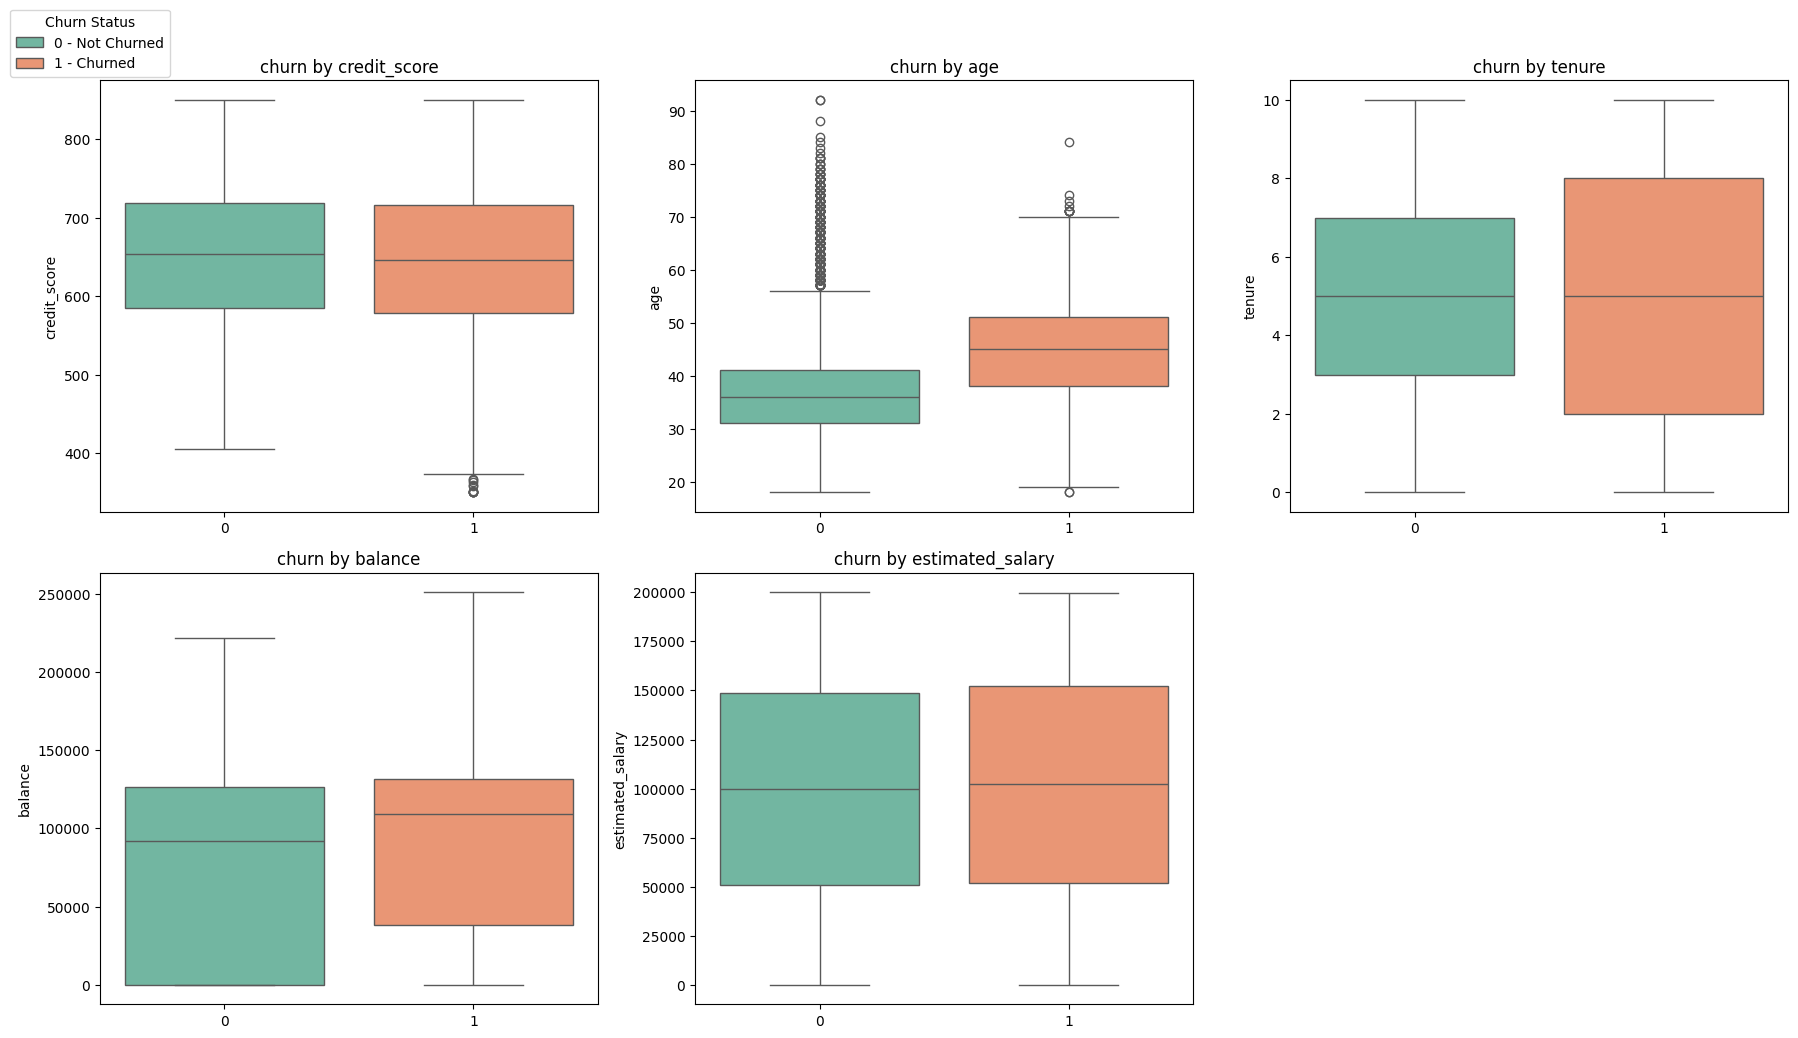

In [6]:
# Create boxplots for numeric variables only

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='churn', y=col, hue='churn', data=df, palette='Set2', ax=axes[i], legend=True)
    axes[i].set_title(f'churn by {col}')
    axes[i].set_xlabel('')
    axes[i].get_legend().remove() # I'm using a common legend instead

# Remove empty subplot
fig.delaxes(axes[5])

# Create one common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['0 - Not Churned', '1 - Churned'], loc='center left', \
bbox_to_anchor=(0, 1), title='Churn Status')

plt.tight_layout()
plt.show()

### General observations (*cont.*)
#### Categorical features
* **`country`**: 5 in 10 customers are from *France*, while *Spain* and *Germany* almost equally share the other 5. German customers tend to have higher churn rate (~22%) compared to its peers (about 17% each).
* **`gender`**: The distribution of male and female customers are slightly similar. However, *female* customers, about 1 in 4, are likely to churn more than *male* customers.
* **`products_number`**: Albeit represented as integer, I consider this a categorical feature (for this EDA) since the numbers look like it pertains to a category rather than a continuous measure. Almost 97% of the customers have product_numbers 1 and 2. Customers with product_number 2 are almost 4x less likely to churn than those with product_number 1.
* **`credit_card`**: 1 in 5 customers with credit card (`1`) have churned, the same as those without credit card (`0`).
* **`active_member`**: Non-active members (`0`) are twice as likely to churn than active members (`1`).

In [7]:
cat_cols = ['country', 'gender', 'products_number', 'credit_card', 'active_member']

# Summary statistics for cat_cols
cat_stats_list = []
for col in cat_cols:
    counts = df[col].value_counts().rename('Count')
    proportions = (df[col].value_counts(normalize=True) * 100).rename('Percentage (%)').round(2)
    temp_df = pd.concat([counts, proportions], axis=1)
    temp_df.index.name = 'Category Value'
    temp_df['Variable'] = col
    cat_stats_list.append(temp_df.reset_index())

combined_cat_stats = pd.concat(cat_stats_list).set_index(['Variable', 'Category Value'])

print("\nCategory Statistics for non-Numeric Columns:")
display(combined_cat_stats.T)


Category Statistics for non-Numeric Columns:


Variable        country                     gender          products_number  \
Category Value   France  Germany    Spain     Male   Female               1   
Count           5014.00  2509.00  2477.00  5457.00  4543.00         5084.00   
Percentage (%)    50.14    25.09    24.77    54.57    45.43           50.84   

Variable                             credit_card          active_member  \
Category Value       2       3     4           1        0             1   
Count           4590.0  266.00  60.0     7055.00  2945.00       5151.00   
Percentage (%)    45.9    2.66   0.6       70.55    29.45         51.51   

Variable                 
Category Value        0  
Count           4849.00  
Percentage (%)    48.49

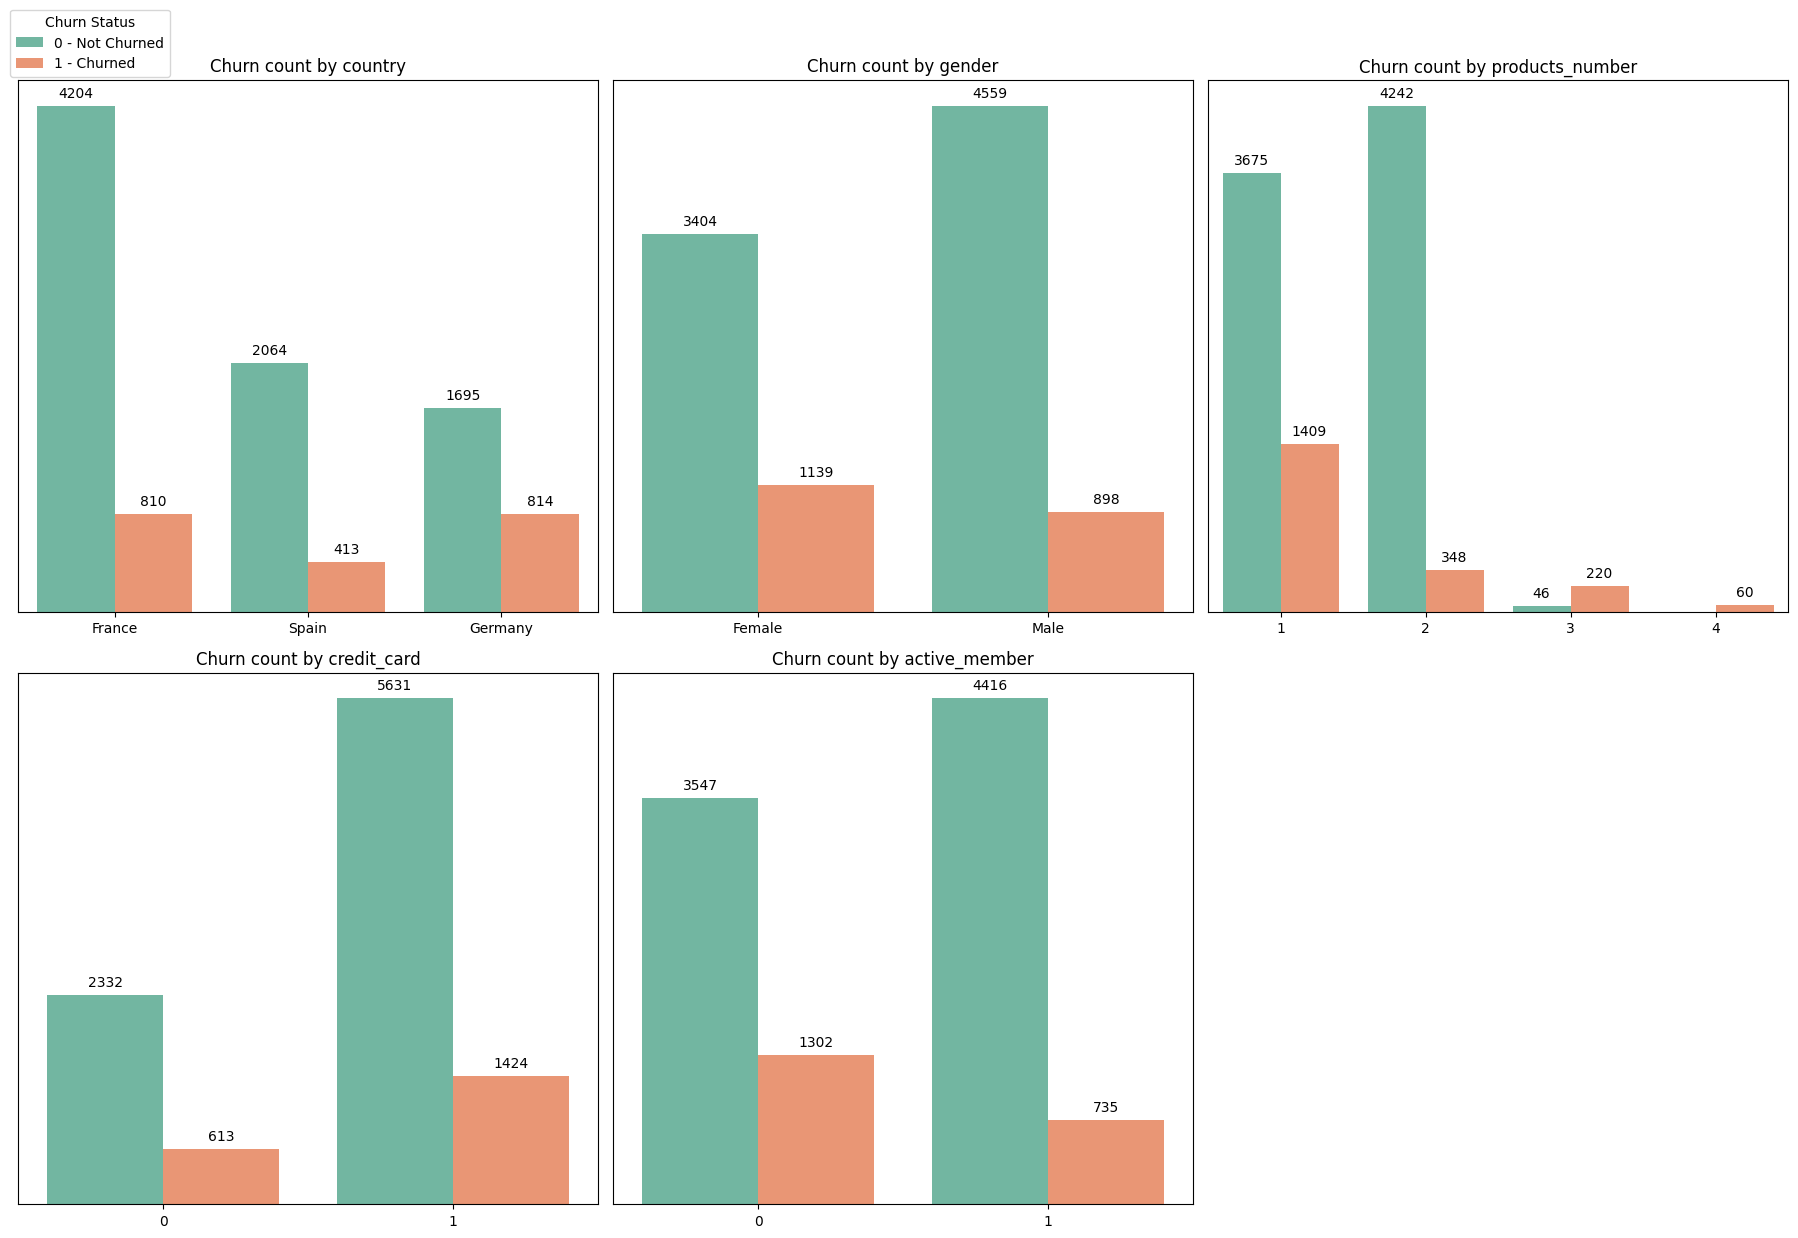

In [8]:
# Set up the figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = sns.countplot(x=col, hue='churn', data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn count by {col}')

    # Remove x and y axis labels and y-axis ticks/scale
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_yticklabels([])
    axes[i].set_yticks([])

    # Remove individual legends
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

    # Add labels on top of each bar
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points')

# Create one common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['0 - Not Churned', '1 - Churned'], loc='center left', \
bbox_to_anchor=(0, 1), title='Churn Status')

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Multicollinearity

Multicollinearity is a diagnostic check to identify features in your data that may be highly correlated with other features. We almost always don't want highly correlated features since it provides unreliable (or inflated) model estimates, which will in turn, affect our accuracy.

In this section, I explored the relationship across predictor variables to identify a set of non-related predictors that we will use in training the model.

Since we're dealing with some nominal variables (i.e. gender, country), we need to convert this to a numeric format first for it to be processed by the model (although some models may allow nominal values, for the purposes of this exercise, we're converting every feature to numeric).

### General observations
* None of the predictor variables appear to have high correlation with other variables.
* This is also evident from the variance inflation factor of scaled predictors. We can use all the features for our model training.
* Among the numeric variables (during EDA), the shape of the distribution are generally normal except for `balance` where you have high zero (0) values.

In [9]:
df_model = df.drop(columns=['customer_id'])

# Preprocessing: Encode categorical variables (country and gender)
le = LabelEncoder()
# This will return 0 for Female and 1 for Male
df_model['gender'] = le.fit_transform(df_model['gender'])
# Using get_dummies since country has more than 2 categories
# This will produce 2 columns: country_Germany and country_Spain
# `France` if both of these columns are zero (0)
df_model = pd.get_dummies(df_model, columns=['country'], drop_first=True).astype(int)

# Define features (X) and target (y)
X = df_model.drop(columns=['churn'])
y = df_model['churn']

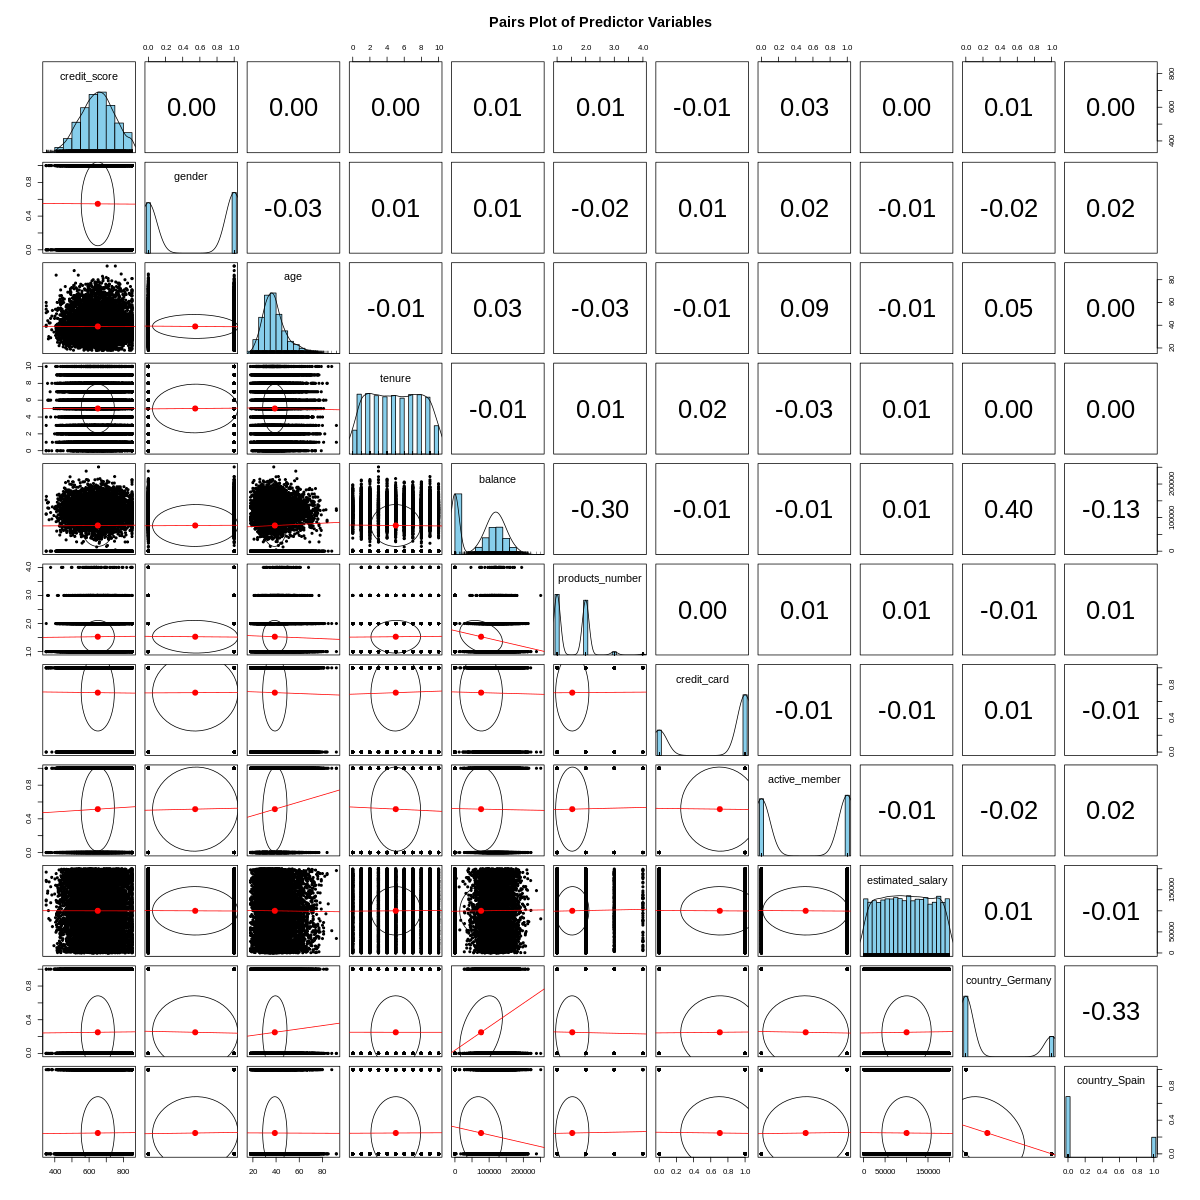

In [10]:
%%R -i X -w 1200 -h 1200
pairs.panels(X[,1:11], # predictor variables only
             method = "pearson", # correlation method
             hist.col = "skyblue",
             lm = TRUE, # add linear regression line
             density = TRUE,  # show density plots
             ellipses = TRUE, # show correlation ellipses
             main = "Pairs Plot of Predictor Variables"
             )

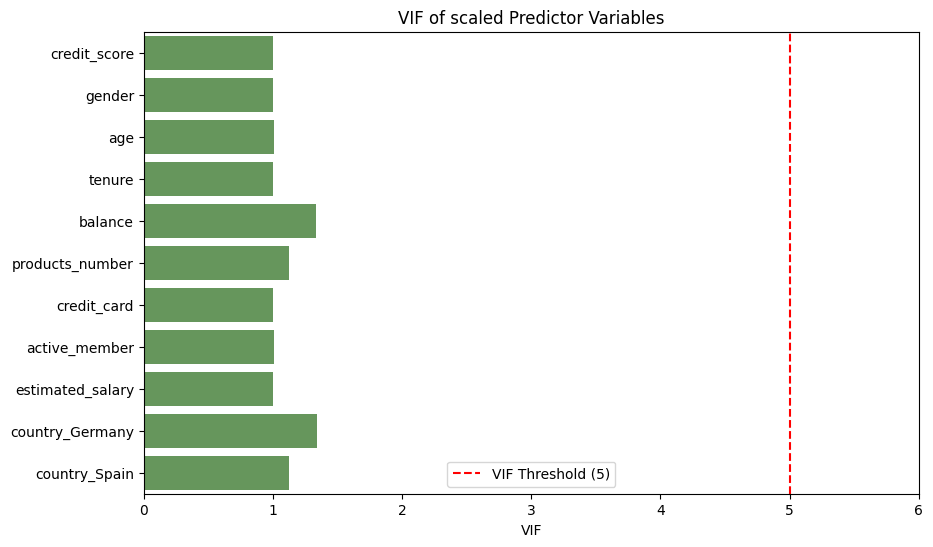

In [11]:
# Calculate the variance inflation factor (VIF) across predictor variables
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Calculate VIF for each scaled feature
vif_data = pd.DataFrame()
vif_data['feature'] = X_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

# Plotting the VIF values
plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='feature', data=vif_data, color='#5FA052')
# Add the horizontal line with a label for the legend
plt.axvline(x=5, color='red', linestyle='--', label='VIF Threshold (5)')
plt.xlim(0, 6)
plt.ylabel('')
plt.title('VIF of scaled Predictor Variables')
plt.legend()
plt.show()

### Preliminary Correlation
I added this section to get a better understanding of the relationship between churn and each of the predictors. By looking at this alone, we can say that none of the predictors have a strong relationship (positive or negative) with churn. `age` and `country_germany` seem to have the highest positive relationship, whereas `active_member` has the highest negative relationship. This information may or may not hold water once we use a classification model to predict churn.

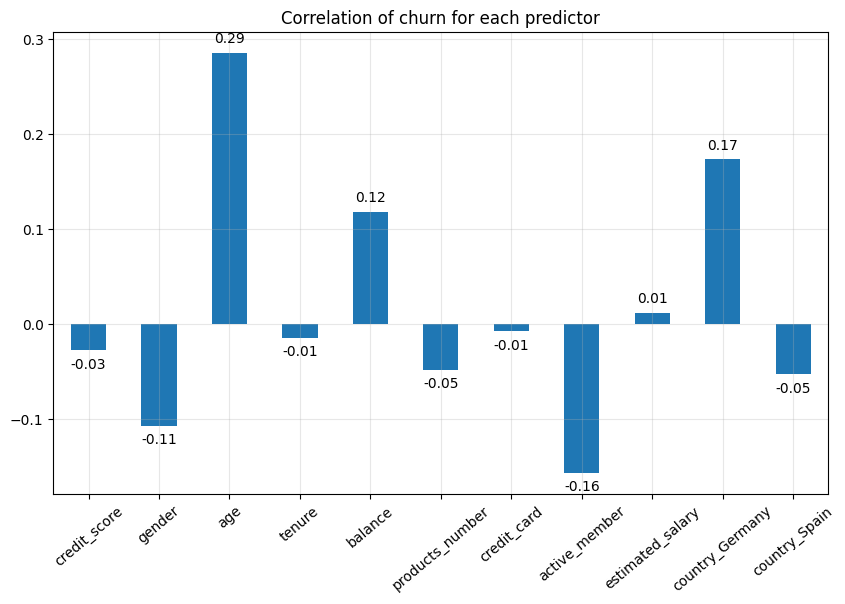

In [12]:
# Correlate churn for each of the predictor variables
corr_series = X.corrwith(y)
ax = corr_series.plot.bar(figsize=(10,6), grid=True, rot=40)
plt.grid(alpha=0.3)
plt.title('Correlation of churn for each predictor')

# Add labels
for p in ax.patches:
    val = p.get_height()
    # Determine offset direction based on value
    va = 'bottom' if val >= 0 else 'top'
    xy_text = (0, 5) if val >= 0 else (0, -5)

    ax.annotate(f'{val:.2f}',
                (p.get_x() + p.get_width() / 2., val),
                ha='center', va=va,
                xytext=xy_text,
                textcoords='offset points')

plt.show()

## Train Model

We split the data into train (80%) and test (20%) sets so we could evaluate the model performance later on. We stratify the split to ensure we have enough samples of both churn and non-churn customers in train and test sets.  Furthermore, since the predictor variables are of different scales, we apply transformations to the *X_train* (`fit_transform`) and *X_test* (`transform`) sets.

In [13]:
# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=0,
                                                    stratify=y)

# We're using the same standardization from VIF and apply to x variables
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (8000, 11)
Test set shape: (2000, 11)


### Benchmark: Logistic Regression
To establish a performance benchmark, I'm using the classic *Logistic Regression* model to predict the customer's likelihood to churn. This model will be compared against advanced binary classification models.

In [14]:
%%time
# Initialize and fit the model
lr_model = LogisticRegression(random_state=0)
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Calculate metrics
metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob)
}

# Create a comparison table
model_performance = pd.DataFrame([metrics])

print("Logistic Regression Evaluation Metrics:")
display(model_performance)

Logistic Regression Evaluation Metrics:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.809,0.582781,0.216216,0.315412,0.765963


CPU times: user 130 ms, sys: 968 µs, total: 131 ms
Wall time: 141 ms


### Advanced Binary Classification Models

I'm using a suite of advanced binary classification models to identify the best performing model capable of predicting a customer's likelihood to churn.

* Generally, all the advanced models outperformed logistic regression across every performance metrics (which might justify compute costs given the amount of resources needed to train these models).
* Based on the performance metrics, `Random Forest` seem to provide a good balance of *precision* (correctly identifying loyal customers and churners) and *recall* (minimizing misclassified churners).
* Particularly in the banking sector, missing a customer who is about to leave (False Negative) is often more costly than mistaking a loyal customer of leaving (False Positive).
* Although `XGBoost` performed well by classifying the least False Negatives (Type 2 error), it's not remotely far from `Random Forest` who performed well in other metrics.

In [15]:
%%time
# Define the advanced models
advanced_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=0),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=0, eval_metric='logloss'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=0),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=0),
    'SVM': SVC(kernel='rbf', probability=True, random_state=0)
}

# Use the existing table from the previous code block
model_performance = model_performance[model_performance['Model'] == 'Logistic Regression']

for name, model in advanced_models.items():
    # Fit model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    }

    # Append metrics
    model_performance = pd.concat([model_performance, pd.DataFrame([metrics])], ignore_index=True)

print("Final Model Performance Comparison:")
display(model_performance.round(3))

Final Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.809,0.583,0.216,0.315,0.766
1,Random Forest,0.860,0.753,0.464,0.574,0.844
2,XGBoost,0.852,0.701,0.472,0.564,0.823
3,GradientBoosting,0.858,0.758,0.440,0.557,0.858
4,AdaBoost,0.851,0.761,0.391,0.516,0.834
5,SVM,0.854,0.837,0.354,0.497,0.824


CPU times: user 15.8 s, sys: 224 ms, total: 16 s
Wall time: 18.5 s


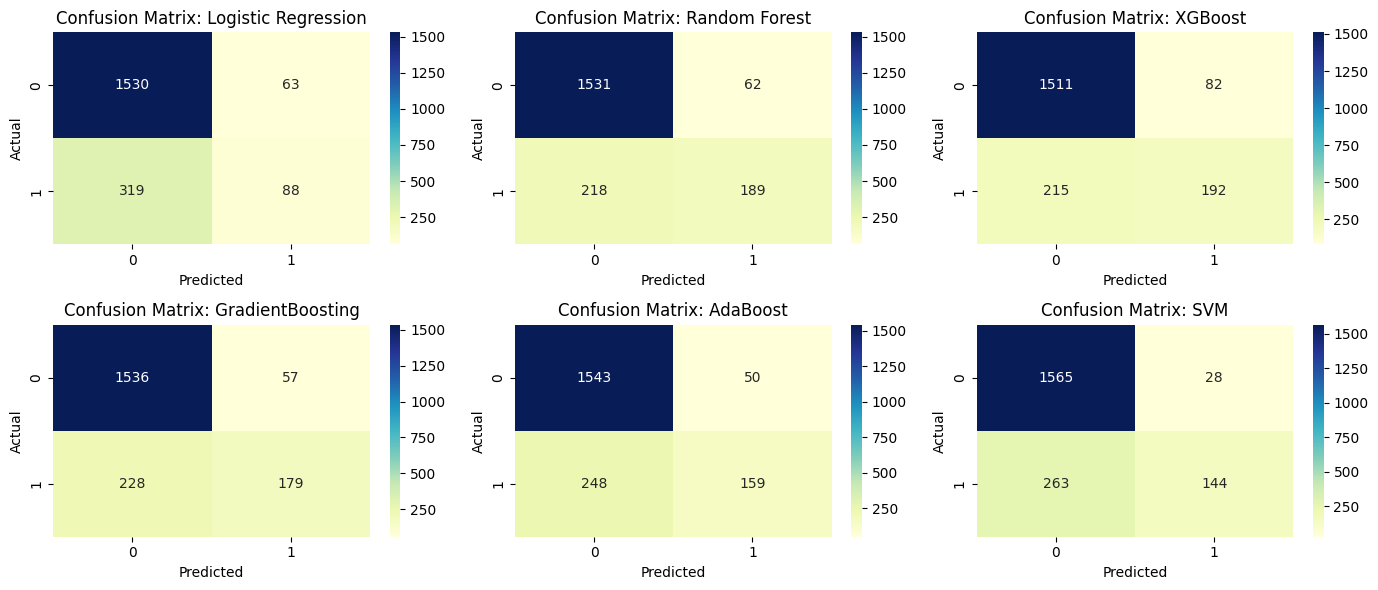

In [16]:
# Define all models we have trained
# Pulling the models from the advanced_models dictionary to avoid NameErrors
models_to_plot = {
    'Logistic Regression': lr_model,
    'Random Forest': advanced_models['Random Forest'],
    'XGBoost': advanced_models['XGBoost'],
    'GradientBoosting': advanced_models['GradientBoosting'],
    'AdaBoost': advanced_models['AdaBoost'],
    'SVM': advanced_models['SVM']
}

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for i, (name, model) in enumerate(models_to_plot.items()):
    # Get predictions
    y_pred_current = model.predict(X_test)
    # Compute confusion matrix
    cm_current = confusion_matrix(y_test, y_pred_current)

    # Plot heatmap
    sns.heatmap(cm_current, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Top 10 Customers Most Likely to Churn (including predicted classification):


,customer_id,churn_probability,predicted_churn
0,15740223,1.00,1
1,15753174,1.00,1
2,15579212,1.00,1
3,15570002,1.00,1
4,15787189,1.00,1
5,15766355,1.00,1
6,15623210,1.00,1
7,15596013,1.00,1
8,15793455,1.00,1
9,15792305,0.99,1


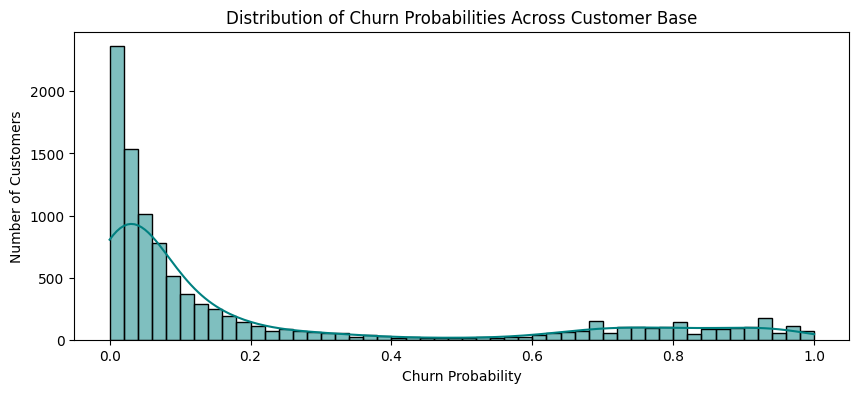

In [17]:
# Get the trained Random Forest model
rf_model = advanced_models['Random Forest']

# Use the same scaler that was fitted on the training data
X_all_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns)

# Get probability for the positive class (churn = 1)
churn_probabilities = rf_model.predict_proba(X_all_scaled)[:, 1]

# Get the classification (0 or 1)
churn_predictions = rf_model.predict(X_all_scaled)

# Create a ranking dataframe with probability and classification
rankings = pd.DataFrame({
    'customer_id': df['customer_id'],
    'churn_probability': churn_probabilities,
    'predicted_churn': churn_predictions
})

# Sort by probability descending
rankings = rankings.sort_values(by='churn_probability', ascending=False).reset_index(drop=True)

print("Top 10 Customers Most Likely to Churn (including predicted classification):")
display(rankings.head(10))

# Summary of the ranking distribution
plt.figure(figsize=(10, 4))
sns.histplot(rankings['churn_probability'], bins=50, kde=True, color='teal')
plt.title('Distribution of Churn Probabilities Across Customer Base')
plt.xlabel('Churn Probability')
plt.ylabel('Number of Customers')
plt.show()

## Cut-off Determination

The analysis in this section helps us determine the most effective probability threshold for classification:

* By maximizing the **F1-Score**, we find that a cutoff of 0.38 (rather than the default 0.50) provides the best balance between **Precision** and **Recall**.
* If the bank's priority is to catch *every* potential churner (regardless of false alarms), we would lower the threshold further.
* If the bank has limited resources for retention campaigns and only wants to target those most certain to leave, we would raise this threshold.
* Using **0.38** as our decision rule allows us to capture a significant portion of churners while maintaining a reasonable level of accuracy in our predictions.

Optimal Threshold (Max F1-Score): 0.3800
Maximum F1-Score at this threshold: 0.6053


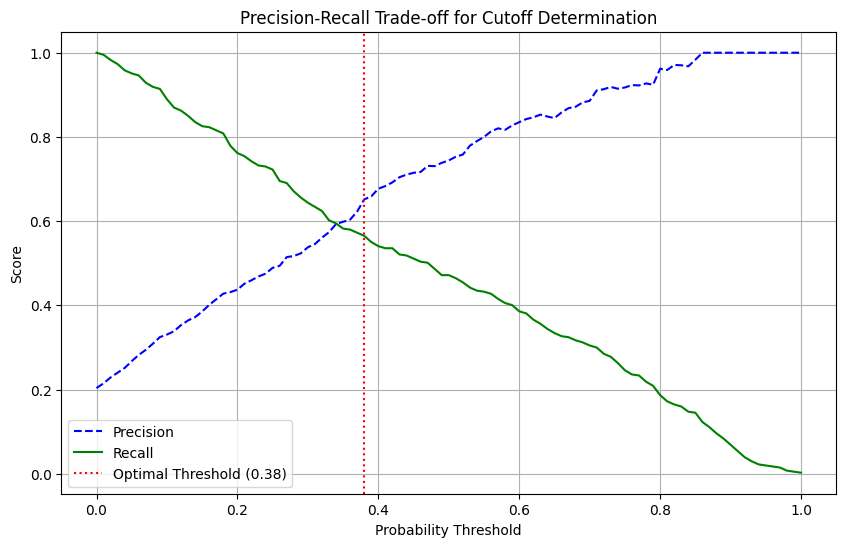

In [18]:
# Calculate precision and recall for various thresholds
# We use the test set for an unbiased evaluation of the threshold
y_prob_test = rf_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# Calculate F1 scores for each threshold
# f1 = 2 * (precision * recall) / (precision + recall)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# Find the threshold that maximizes F1-Score
opt_idx = np.argmax(f1_scores)
opt_threshold = thresholds[opt_idx]
opt_f1 = f1_scores[opt_idx]

print(f'Optimal Threshold (Max F1-Score): {opt_threshold:.4f}')
print(f'Maximum F1-Score at this threshold: {opt_f1:.4f}')

# Plot the decision rule
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.axvline(x=opt_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({opt_threshold:.2f})')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off for Cutoff Determination')
plt.legend()
plt.grid(True)
plt.show()

## Key Drivers of Churn

Based on the feature importance, `age` is by far the most influential driver of churn. This is followed by `estimated_salary`, `credit_score`, and `balance`.

* `age` is the strongest predictor. Older customers tend to have different banking behaviors or might be more sensitive to service changes.
* `estimated_salary` and `credit_score` are both financial health markers. This may suggest that the customer's economic profile significantly impacts their likelihood to stay.
* The amount of money held (`balance`) and the number of products (or services?) used (`product_number`) are also critical. For instance, customers with only one product or very high/low balances might be 'at-risk' segments.

PS. Creating new features would have probably improved the model performance and this feature importance. For instance, (1) bucketing the age to further stratify churn distribution across age groups (e.g. young professionals vs seniors, etc.), (2) bucketing the tenure to compare for instance new vs long-term customers, and (3) calculating ratios e.g. estimated salary in relation to balance, balance per product number, etc.

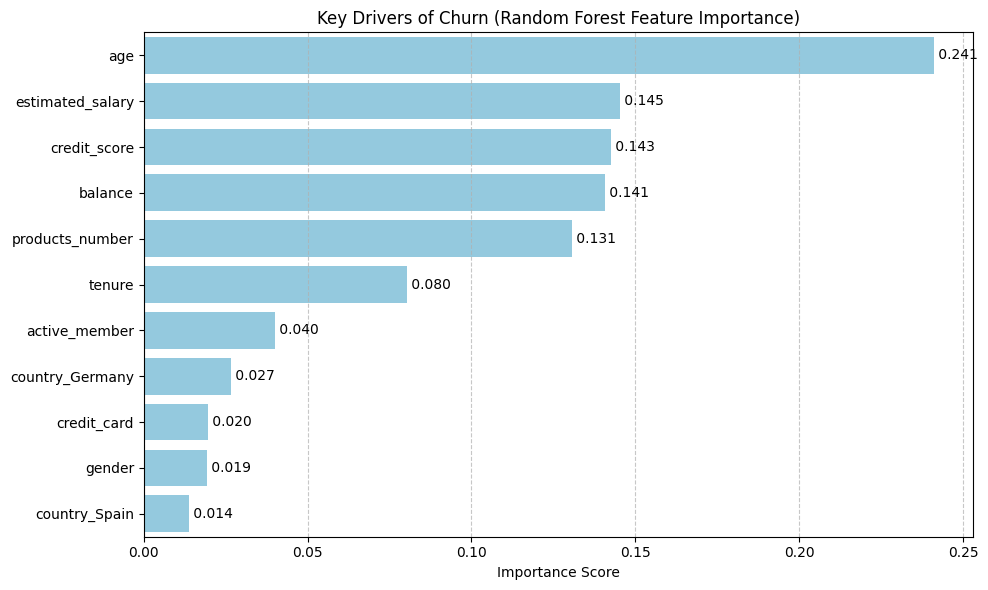

In [19]:
# Feature importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances, color='skyblue')

# Add labels
for i, val in enumerate(importances['importance']):
    plt.text(val, i, f' {val:.3f}', va='center')

plt.title('Key Drivers of Churn (Random Forest Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Particular Segments for Separate Models
* The model shows that `country_Germany` has a higher importance than other locations (same observation during EDA). This suggests that the drivers for churn in Germany might differ from France or Spain possibly due to local competition or different service expectations.
* Since age is the dominant factor, creating separate strategies or models for 'Seniors' vs. 'Young Professionals' could reveal more nuanced (behavioral) patterns that a single global model might average out.